# 02: Benchmark Statistics

Visualizations and statistics for the temporal benchmark.

**Objectives:**
- Compare t0 and t1 snapshots (node/edge counts, type distributions)
- Visualize temporal diffs (added/removed triples)
- Show task sequence composition
- Display multimodal feature coverage

In [1]:
import sys
sys.path.insert(0, '..')

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

# Load benchmark statistics
with open('../data/benchmark/statistics.json') as f:
    stats = json.load(f)

print(f"Benchmark version: {stats['benchmark_version']}")
print(f"Strategy: {stats['strategy']}")
print(f"Build time: {stats['build_time_seconds']}s")
print(f"\nSnapshots:")
print(f"  t0: {stats['snapshots']['t0']['num_triples']:,} triples")
print(f"  t1: {stats['snapshots']['t1']['num_triples']:,} triples")

Benchmark version: 1.0-simulated
Strategy: entity_type
Build time: 108.3s

Snapshots:
  t0: 8,100,498 triples
  t1: 8,414,448 triples


## 1. Temporal Diff Statistics

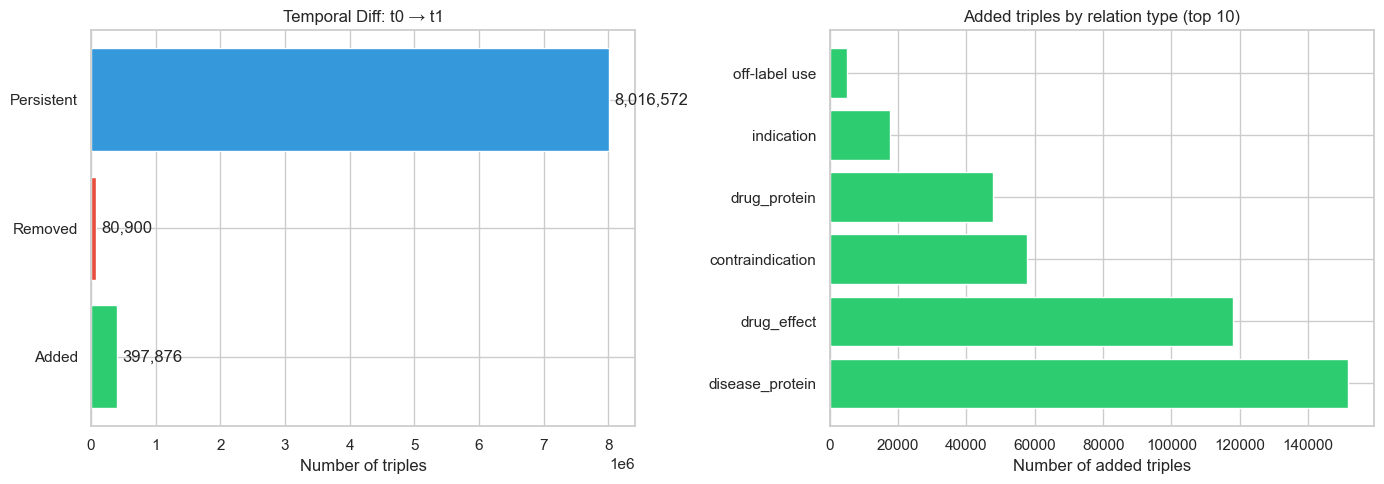

In [2]:
# Load diff report
with open('../data/benchmark/diffs/diff_t0_t1.json') as f:
    diff = json.load(f)

# Diff summary bar chart
diff_data = diff['diff']
labels = ['Added', 'Removed', 'Persistent']
values = [diff_data['added_triples'], diff_data['removed_triples'], diff_data['persistent_triples']]
colors = ['#2ecc71', '#e74c3c', '#3498db']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: bar chart of diff categories
axes[0].barh(labels, values, color=colors)
axes[0].set_xlabel('Number of triples')
axes[0].set_title('Temporal Diff: t0 → t1')
for i, v in enumerate(values):
    axes[0].text(v + max(values)*0.01, i, f'{v:,}', va='center')

# Right: added triples by relation type (top 10)
added_by_rel = diff.get('added_by_relation', {})
if added_by_rel:
    rel_df = pd.DataFrame(sorted(added_by_rel.items(), key=lambda x: -x[1])[:10],
                          columns=['relation', 'count'])
    axes[1].barh(rel_df['relation'], rel_df['count'], color='#2ecc71')
    axes[1].set_xlabel('Number of added triples')
    axes[1].set_title('Added triples by relation type (top 10)')

plt.tight_layout()
plt.savefig('../results/benchmark_diff_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Task Sequence Composition

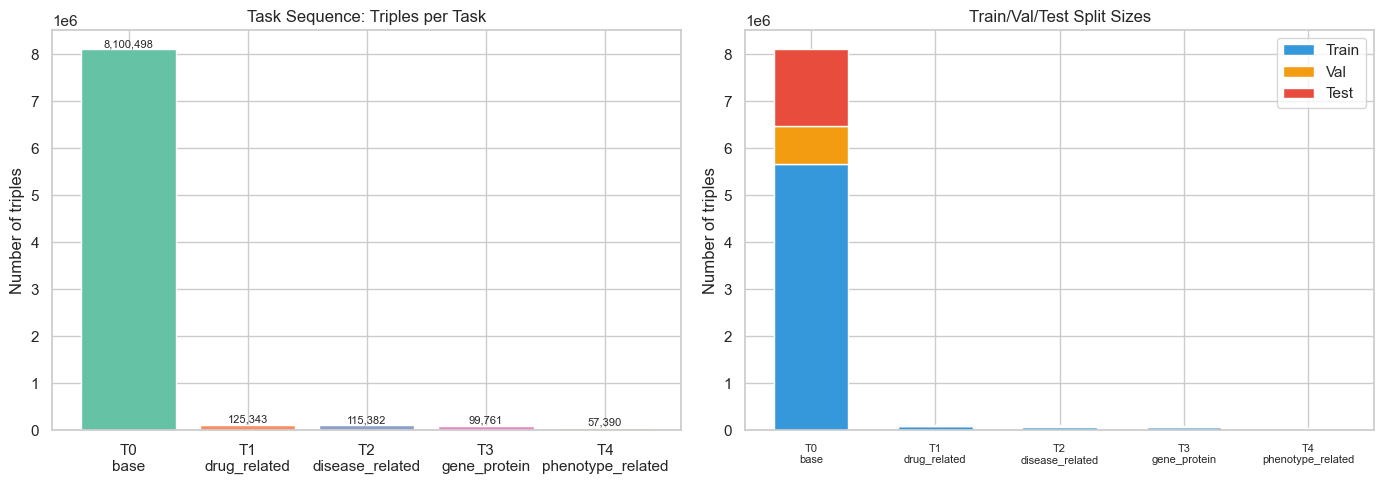

In [3]:
# Task sizes
task_names = []
task_sizes = []
train_sizes = []
val_sizes = []
test_sizes = []

for name, info in stats['tasks'].items():
    task_names.append(name.replace('task_', 'T').replace('_', '\n', 1))
    task_sizes.append(info['num_triples'])
    if info.get('splits'):
        train_sizes.append(info['splits']['train'])
        val_sizes.append(info['splits']['val'])
        test_sizes.append(info['splits']['test'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: total triples per task
bars = axes[0].bar(task_names, task_sizes, color=sns.color_palette('Set2', len(task_names)))
axes[0].set_ylabel('Number of triples')
axes[0].set_title('Task Sequence: Triples per Task')
for bar, size in zip(bars, task_sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                 f'{size:,}', ha='center', va='bottom', fontsize=8)

# Right: stacked bar of train/val/test splits
x = np.arange(len(task_names))
width = 0.6
axes[1].bar(x, train_sizes, width, label='Train', color='#3498db')
axes[1].bar(x, val_sizes, width, bottom=train_sizes, label='Val', color='#f39c12')
axes[1].bar(x, test_sizes, width, bottom=[t+v for t,v in zip(train_sizes, val_sizes)], label='Test', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(task_names, fontsize=8)
axes[1].set_ylabel('Number of triples')
axes[1].set_title('Train/Val/Test Split Sizes')
axes[1].legend()

plt.tight_layout()
plt.savefig('../results/benchmark_task_splits.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Multimodal Feature Coverage

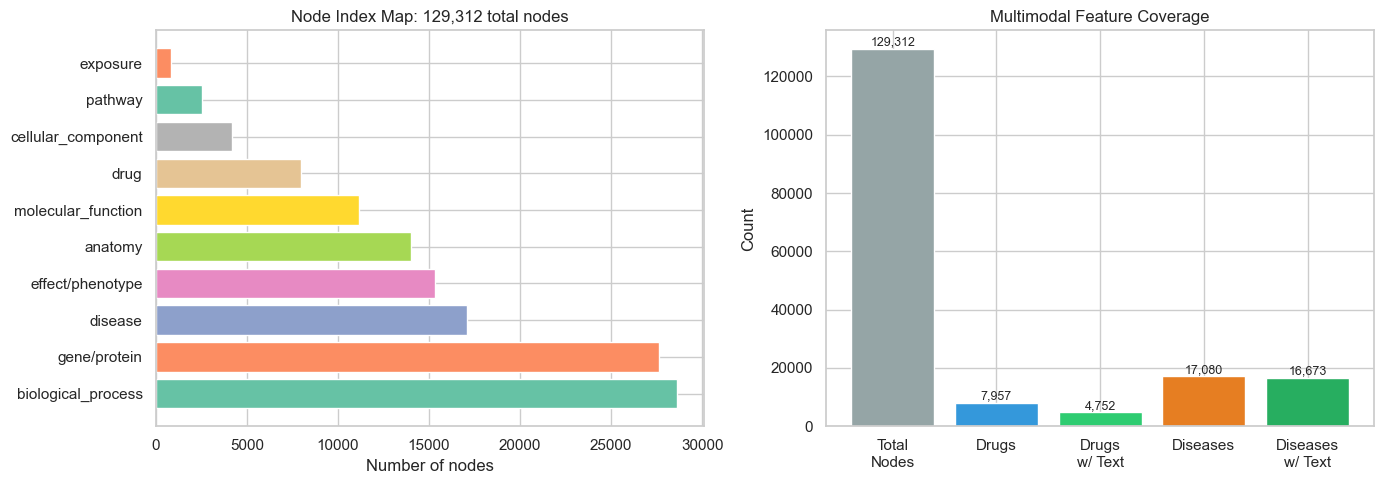


Drug feature columns:
  drug_id: 7,957 (100.0%)
  text: 4,752 (59.7%)
  molecular_weight: 2,797 (35.2%)
  tpsa: 2,718 (34.2%)
  clogp: 2,574 (32.3%)
  group: 7,957 (100.0%)
  state: 6,517 (81.9%)
  has_text: 7,957 (100.0%)


In [4]:
# Load node index map and feature files
node_map = pd.read_csv('../data/benchmark/features/node_index_map.csv')
drug_feat = pd.read_csv('../data/benchmark/features/drug_features.csv')
disease_feat = pd.read_csv('../data/benchmark/features/disease_features.csv')

# Node type distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: nodes by type
type_counts = node_map['node_type'].value_counts()
axes[0].barh(type_counts.index, type_counts.values, color=sns.color_palette('Set2', len(type_counts)))
axes[0].set_xlabel('Number of nodes')
axes[0].set_title(f'Node Index Map: {len(node_map):,} total nodes')

# Right: feature coverage
feat_stats = stats['features']
categories = ['Total\nNodes', 'Drugs', 'Drugs\nw/ Text', 'Diseases', 'Diseases\nw/ Text']
values = [
    feat_stats['total_nodes'],
    feat_stats['num_drugs'],
    feat_stats['drugs_with_text'],
    feat_stats['num_diseases'],
    feat_stats['diseases_with_text'],
]
colors = ['#95a5a6', '#3498db', '#2ecc71', '#e67e22', '#27ae60']
axes[1].bar(categories, values, color=colors)
axes[1].set_ylabel('Count')
axes[1].set_title('Multimodal Feature Coverage')
for i, v in enumerate(values):
    axes[1].text(i, v + max(values)*0.01, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/benchmark_feature_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

# Drug feature column coverage
print("\nDrug feature columns:")
for col in drug_feat.columns:
    non_null = drug_feat[col].notna().sum()
    pct = non_null / len(drug_feat) * 100
    print(f"  {col}: {non_null:,} ({pct:.1f}%)")

## 4. Summary

In [5]:
print("=" * 60)
print("MCGL Temporal Benchmark Summary")
print("=" * 60)
print(f"Version:         {stats['benchmark_version']}")
print(f"Strategy:        {stats['strategy']}")
print(f"Seed:            {stats['seed']}")
print()
print(f"Snapshots:")
print(f"  t0:            {stats['snapshots']['t0']['num_triples']:>12,} triples")
print(f"  t1:            {stats['snapshots']['t1']['num_triples']:>12,} triples")
print()
print(f"Temporal Diff:")
print(f"  Added:         {stats['diff']['added_triples']:>12,}")
print(f"  Removed:       {stats['diff']['removed_triples']:>12,}")
print(f"  Persistent:    {stats['diff']['persistent_triples']:>12,}")
print()
print(f"Tasks: {len(stats['tasks'])}")
for name, info in stats['tasks'].items():
    s = info.get('splits', {})
    print(f"  {name}: {info['num_triples']:,} triples"
          f" (train={s.get('train',0):,}, val={s.get('val',0):,}, test={s.get('test',0):,})")
print()
print(f"Features:")
print(f"  Total nodes:     {stats['features']['total_nodes']:,}")
print(f"  Drugs w/ text:   {stats['features']['drugs_with_text']:,}/{stats['features']['num_drugs']:,}")
print(f"  Diseases w/ text:{stats['features']['diseases_with_text']:,}/{stats['features']['num_diseases']:,}")
print()
print(f"NOTE: Using simulated t1 for development. Replace with real t1")
print(f"(rebuilt from July 2023 database sources) for final experiments.")
print("=" * 60)

MCGL Temporal Benchmark Summary
Version:         1.0-simulated
Strategy:        entity_type
Seed:            42

Snapshots:
  t0:               8,100,498 triples
  t1:               8,414,448 triples

Temporal Diff:
  Added:              397,876
  Removed:             80,900
  Persistent:       8,016,572

Tasks: 5
  task_0_base: 8,100,498 triples (train=5,670,350, val=810,049, test=1,620,099)
  task_1_drug_related: 125,343 triples (train=87,741, val=12,534, test=25,068)
  task_2_disease_related: 115,382 triples (train=80,768, val=11,538, test=23,076)
  task_3_gene_protein: 99,761 triples (train=69,833, val=9,976, test=19,952)
  task_4_phenotype_related: 57,390 triples (train=40,173, val=5,739, test=11,478)

Features:
  Total nodes:     129,312
  Drugs w/ text:   4,752/7,957
  Diseases w/ text:16,673/17,080

NOTE: Using simulated t1 for development. Replace with real t1
(rebuilt from July 2023 database sources) for final experiments.
